<a href="https://colab.research.google.com/github/Mark1507/Kovychev_MLF/blob/main/LAB%2003%20true%20verze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

## Exercise 1.1

write a code that prints the following pattern. Try to use as few loops as possible.

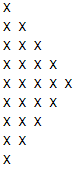

Avoid using trivial solutions like:

print('X')

print('X X')

print('X X X')

.....

print('X X X')

print('X X')

print('X')


In [1]:
for i in range(1, 6):
   print("X " * i)
for i in range(4, 0, -1):
   print("X " * i)

X 
X X 
X X X 
X X X X 
X X X X X 
X X X X 
X X X 
X X 
X 


## Exercise 1.2

Write a script that will sum all numbers in the following string. You can split each number into single digits, so for example, you can consider 45 to be 4 and 5

In [2]:
input_str = "n45as29@#8ss6"
total = 0

for ch in input_str:
    if ch.isdigit():
        total += int(ch)

print(total)


34


## Exercise 1.3

Write a script that will convert an arbitrary integer to a binary number (the number will be represented as a string with only *0* and *1*). Avoid using the *bin()* function or any other pythons default functions

In [3]:
num = int(input("Enter an integer: "))

if num == 0:
    print("0")
else:
    binary = ""
    n = num

    while n > 0:
        remainder = n % 2
        binary = str(remainder) + binary
        n //= 2

    print(binary)


Enter an integer: 4
100


## Exercise 1.4 - The Fibonacci Sequence:

The Fibonacci Sequence is a series of numbers. The following number is found by adding up the two numbers before it. The first two numbers are 0 and 1. For example, 0, 1, 1, 2, 3, 5, 8, 13. The following number in this series above is 8 + 13 = 21


Your task is to implement a function *fibonacci* that takes an integer as an input and returns a list that contains all Fibonacci numbers with values lower than the input integer

Example:

*print(fibonaci(10))*

[0, 1, 1, 2, 3, 5, 8]


In [7]:
def fibonacci(upper_threshold: int) -> list:
    if upper_threshold <= 0:
        return []

    fib = [0, 1]

    while fib[-1] + fib[-2] < upper_threshold:
        fib.append(fib[-1] + fib[-2])

    return fib
print(fibonacci(11))

[0, 1, 1, 2, 3, 5, 8]


#### Advanced

Try to implement the function using multiple approaches: *Iterative approach*, *Recusrion*, *Memoization*

## Exercise 1.5. -  Rock, Paper, Scissors game:

#### basic

*Rock, Paper, Scissors* is a well-known and straightforward game. If you do not know the rules, google them. We will write a code for the Rock, Paper, Scissors game where the user plays against a random computer. The code can be written into one function *rock_paper_scissors*.

Notes:
- This implementation uses the **random** library to enable the computer to make a random choice.
- Keyword **Input** may be helpful. Check it
- After the function is run, the program will ask you about your movement, which you type in
- The game is case-insensitive for user input (e.g., "rock", "Rock", and "ROCK" are all valid).
- This script plays one round of the game.
- The script prints the result ('You lose', 'You win', 'It is a tie')


In [10]:
import random

def rock_paper_scissors() -> None:
    options = ["rock", "paper", "scissors"]

    user_move = input("Your move (rock, paper, scissors): ").strip().lower()

    if user_move not in options:
        print("Invalid input")
        return

    computer_move = random.choice(options)
    print(f"Computer chose: {computer_move}")

    if user_move == computer_move:
        print("It is a tie")
    elif (
        (user_move == "rock" and computer_move == "scissors") or
        (user_move == "paper" and computer_move == "rock") or
        (user_move == "scissors" and computer_move == "paper")
    ):
        print("Win")
    else:
        print("Lose")


rock_paper_scissors()


Your move (rock, paper, scissors): rock
Computer chose: rock
It is a tie


#### Advanced

Extend the Rock, Paper, Scissors game to be able to play *n* rounds.

Notes:
- The scrips will contain two counters - user score and computer score
- After each run, the script prints the current scores and rounds.
- When the number of rounds is reached, the script prints the result ('You lose', 'You win', 'It is a tie')

# Exercise 2

The purpose of this excercise is to practise working with NumPy library

## Exercise 2.1


In this exercise, you will work with NumPy arrays and learn how to efficiently modify and process them using both loops and vectorized operations. Your task is to:

1. Implement the function *create_array_nxn* that generates an n×n NumPy array filled with numbers from n² - 1 down to 0
2. Using a loop-based approach (for-loop, while-loop), implement the function *apply_threshold_loop* that takes any NumPy array and replaces all numbers below a user-defined threshold with 0.
3. Implement function *apply_threshold_vectorized* that performs the same operation as *apply_threshold_loop*, but without loops, using NumPy vectorized operations
4. Implement function *compare_performance* that compares the execution time of functions *apply_threshold_vectorized* and *apply_threshold_loop* with **time** library and print the results


**Additional Notes**:

- Ensure n is a positive integer (n > 0).
- Use the time library to measure execution times for performance comparison.
- The function *compare_performance(n, threshold)* should:
    - Generate an n×n array.
    - Apply both loop-based and vectorized thresholding.
    - Print execution times.

In [15]:
import numpy as np
import time


def create_array_nxn(n: int) -> np.ndarray:
    if n <= 0:
        raise ValueError("n must be a positive integer")

    return np.arange(n*n - 1, -1, -1).reshape(n, n)


def apply_threshold_loop(arr: np.ndarray, threshold: int) -> np.ndarray:
    result = arr.copy()

    rows, cols = result.shape
    for i in range(rows):
        for j in range(cols):
            if result[i, j] < threshold:
                result[i, j] = 0

    return result


def apply_threshold_vectorized(arr: np.ndarray, threshold: int) -> np.ndarray:
    result = arr.copy()
    result[result < threshold] = 0
    return result


def compare_performance(n: int, threshold: int) -> None:
    print(f"Generating {n}x{n} array...")
    arr = create_array_nxn(n)

    print("Running loop version...")
    start = time.time()
    _ = apply_threshold_loop(arr, threshold)
    loop_time = time.time() - start

    print("Running vectorized version...")
    start = time.time()
    _ = apply_threshold_vectorized(arr, threshold)
    vector_time = time.time() - start

    print("\n=== Performance Results ===")
    print(f"Loop time:       {loop_time:.6f} seconds")
    print(f"Vectorized time: {vector_time:.6f} seconds")
    print(f"Speedup:         {loop_time / vector_time:.2f}x faster")



compare_performance(1000, 200000)


Generating 1000x1000 array...
Running loop version...
Running vectorized version...

=== Performance Results ===
Loop time:       0.159140 seconds
Vectorized time: 0.003164 seconds
Speedup:         50.29x faster


## Exercise 2.2 - Digi display

#### basic

The task will be to create a simulation of a Digi display that will be able to display an arbitrary integer
   
*hint: to show the image, use the library matplotlib.pyplot. Also, you may find function *np.concatenate* helpful

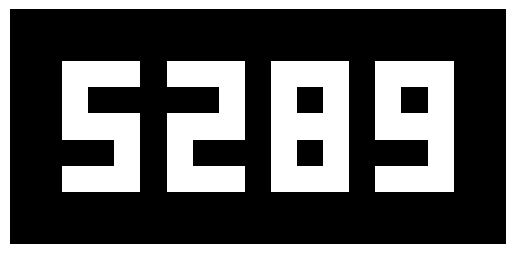

In [33]:
import numpy as np
import matplotlib.pyplot as plt

numbs = {
    "1": np.array([[0, 1, 1], [1, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1]]),
    "2": np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [1, 0, 0], [1, 1, 1]]),
    "3": np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]),
    "4": np.array([[1, 0, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [0, 0, 1]]),
    "5": np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [0, 0, 1], [1, 1, 1]]),
    "6": np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [1, 0, 1], [1, 1, 1]]),
    "7": np.array([[1, 1, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1]]),
    "8": np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [1, 0, 1], [1, 1, 1]]),
    "9": np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]),
    "0": np.array([[1, 1, 1], [1, 0, 1], [1, 0, 1], [1, 0, 1], [1, 1, 1]]),
}


def show_in_digi(input_integer: int) -> None:
    digits = list(str(input_integer))

    space = np.zeros((5, 1))

    matrices = []
    for d in digits:
        matrices.append(numbs[d])
        matrices.append(space)

    matrices = matrices[:-1]

    full_matrix = np.concatenate(matrices, axis=1)

    full_matrix = np.pad(full_matrix, pad_width=2, mode='constant', constant_values=0)

    plt.imshow(full_matrix, cmap="gray")
    plt.axis("off")
    plt.show()

show_in_digi(5289)

show_in_digi(5289) will show:


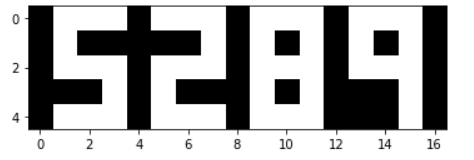

*hint2: you may find the following dict usefull*

In [ ]:
numbs = {
      "1": np.array([[0, 1, 1], [1, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1]]), # 1
      "2": np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [1, 0, 0], [1, 1, 1]]), # 2
      "3": np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 3
      "4": np.array([[1, 0, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [0, 0, 1]]), # 4
      "5": np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 5
      "6": np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [1, 0, 1], [1, 1, 1]]), # 6
      "7": np.array([[1, 1, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1]]), # 7
      "8": np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [1, 0, 1], [1, 1, 1]]), # 8
      "9": np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 9
      "0": np.array([[1, 1, 1], [1, 0, 1], [1, 0, 1], [1, 0, 1], [1, 1, 1]]), # 0
  }

#### advanced

Extend your *show_in_digi* function to be able to display an arbitary float number and negative numbers

# Exercise 3 - Playing with California Housing Dataset

The purpose of this exercise is to learn basic operations of **pandas** library. Use *california_housing_dataset* you can find in google colab to do following operations:

- check what *dataset.describe()* does

- display all rows where *total_bedrooms* column is bigger than 310

- drop also first and last row

- save a mean of values in *households* columns to variable, using *matplotlib* display number of households in the graph (x-axis would be ID, y-axis - numbers of households) as dots with the same color, display also mean as a single line in the graph with different color as dots is

 - check if any of the columns contain NaN values, if yes, replace the NaN values with the arithmetic mean of the whole dataset

 - display *lat* and *long* into plot, *lat* would be on *x* axis and *long* on *y* axis

- choose two arbitrary columns and normalize all values inside using *min-max normalization*:

- Create a Correlation Matrix from all columns

=== DESCRIBE ===
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.69

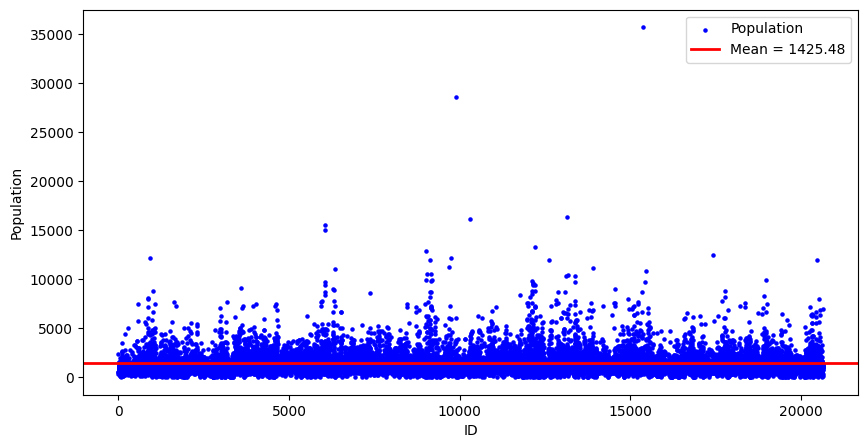


=== CHECKING FOR NaN VALUES ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


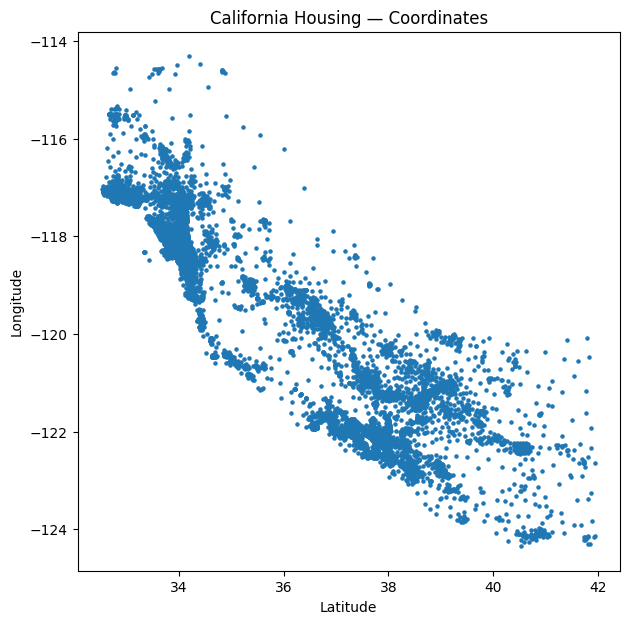


=== NORMALIZED COLUMNS ===
     MedInc  AveRooms
0  0.539668  0.043512
1  0.538027  0.038224
2  0.466028  0.052756
3  0.354699  0.035241
4  0.230776  0.038534


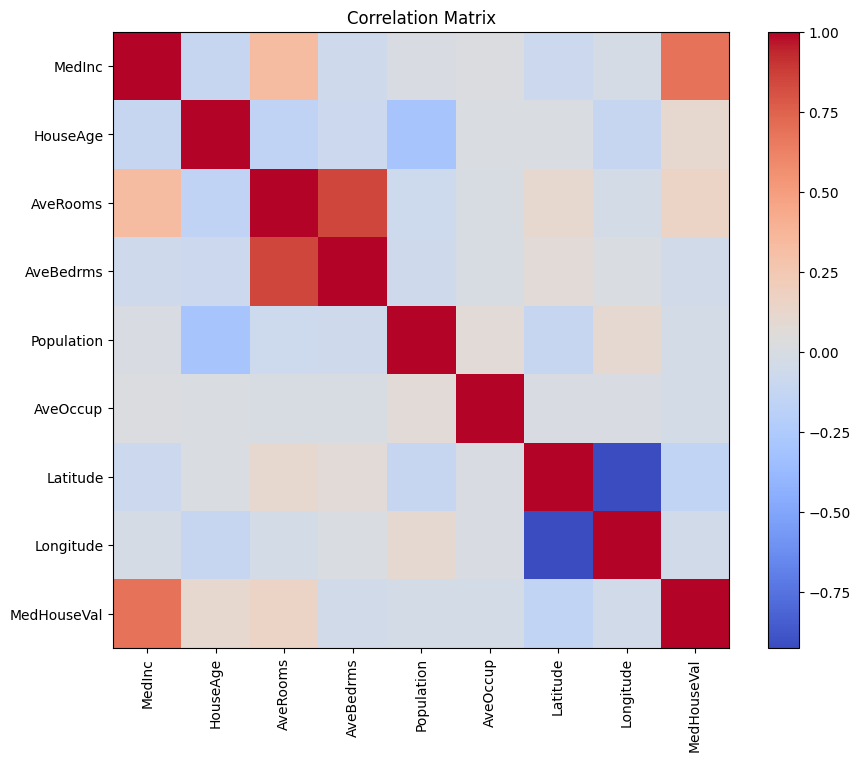

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
import numpy as np

# ============================
# 1. Load dataset
# ============================
data = fetch_california_housing(as_frame=True)
df = data.frame

print("=== DESCRIBE ===")
print(df.describe())


# ============================
# 2. Display rows where total_bedrooms > 310
# ============================
print("\n=== ROWS WHERE AveBedrms > 1.5 ===")
filtered = df[df["AveBedrms"] > 1.5]
print(filtered)



# ============================
# 3. Drop first and last row
# ============================
df_dropped = df.iloc[1:-1]
print("\n=== FIRST AND LAST ROW DROPPED ===")
print(df_dropped.head())


# ============================
# 4. Plot households + mean line
# ============================
mean_population = df["Population"].mean()

plt.figure(figsize=(10, 5))
plt.scatter(df.index, df["Population"], s=5, color="blue", label="Population")
plt.axhline(mean_population, color="red", linewidth=2, label=f"Mean = {mean_population:.2f}")

plt.xlabel("ID")
plt.ylabel("Population")
plt.legend()
plt.show()


# ============================
# 5. Replace NaN with column means
# ============================
print("\n=== CHECKING FOR NaN VALUES ===")
print(df.isna().sum())

if df.isna().any().any():
    df = df.fillna(df.mean(numeric_only=True))
    print("\nNaN values replaced with column means.")


# ============================
# 6. Plot latitude vs longitude
# ============================
plt.figure(figsize=(7, 7))
plt.scatter(df["Latitude"], df["Longitude"], s=5)
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("California Housing — Coordinates")
plt.show()


# ============================
# 7. Min-max normalization of two columns
# ============================
cols = ["MedInc", "AveRooms"]
df_norm = df.copy()

for col in cols:
    min_val = df[col].min()
    max_val = df[col].max()
    df_norm[col] = (df[col] - min_val) / (max_val - min_val)

print("\n=== NORMALIZED COLUMNS ===")
print(df_norm[cols].head())


# ============================
# 8. Correlation matrix
# ============================
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()
